In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

# ==========================================
# 1. ПАРАМЕТРЫ И ТЕОРИЯ
# ==========================================
# Вариант 10: P(k) = 2^(-k-1). Это Геометрическое распр. с p = 0.5
P_PARAM = 0.5
SAMPLE_SIZE = 1000  # Объем выборки (n)

# Теоретические характеристики для Геометрического (версия с 0, 1, ...):
# Мат. ожидание M = (1-p)/p
theoretical_mean = (1 - P_PARAM) / P_PARAM
# Дисперсия D = (1-p)/p^2
theoretical_var = (1 - P_PARAM) / (P_PARAM ** 2)

print(f"--- ВАРИАНТ 10 ---")
print(f"Теоретическое M[x]: {theoretical_mean}")
print(f"Теоретическая D[x]: {theoretical_var}")
print("-" * 40)

--- ВАРИАНТ 10 ---
Теоретическое M[x]: 1.0
Теоретическая D[x]: 2.0
----------------------------------------


In [2]:
# ==========================================
# 2. РЕАЛИЗАЦИЯ АЛГОРИТМА (Стр. 6, п. 2.4)
# ==========================================
def generate_geometric(n, p):
    """
    xi = [ ln(alpha) / ln(1-p) ], где alpha - БСВ [0,1]
    """
    # Шаг 1: Моделирование БСВ alpha (Uniform 0..1)
    alpha = np.random.uniform(0, 1, n)
    
    # Шаг 2: Вычисление по формуле
    xi = np.floor(np.log(alpha) / np.log(1 - p))
    
    return xi.astype(int)

# Генерация выборки
sample = generate_geometric(SAMPLE_SIZE, P_PARAM)

# Создаем DataFrame для анализа
df = pd.DataFrame({'val': sample})

In [ ]:
# ==========================================
# 3. ПРОВЕРКА ГЕНЕРАТОРА (Оценки моментов)
# ==========================================
sample_mean = df['val'].mean()
sample_var = df['val'].var(ddof=1)  # несмещенная оценка

print(f"Выборочное среднее: {sample_mean:.4f} (Отклонение: {abs(sample_mean - theoretical_mean):.4f})")
print(f"Выборочная дисперсия: {sample_var:.4f} (Отклонение: {abs(sample_var - theoretical_var):.4f})")

# Коэффициент использования БСВ 1
print("-" * 40)

Выборочное среднее: 1.0090 (Отклонение: 0.0090)
Выборочная дисперсия: 2.1591 (Отклонение: 0.1591)
Коэффициент использования БСВ: 1 (так как 1 число alpha дает 1 число xi)
----------------------------------------


In [ ]:
# ==========================================
# 4. ПРОВЕРКА ГИПОТЕЗЫ (КРИТЕРИЙ ПИРСОНА / ХИ-КВАДРАТ)
# ==========================================
counts = df['val'].value_counts().sort_index() # подсчет сколько раз выпала каждая величина
chi_data = pd.DataFrame({'k': counts.index, 'observed': counts.values})

# Считаем теоретические вероятности P(k) = p * (1-p)^k
chi_data['prob'] = P_PARAM * (1 - P_PARAM) ** chi_data['k']
chi_data['expected'] = chi_data['prob'] * SAMPLE_SIZE

'''Группировка малочисленных частот. Для корректности хи-квадрат ожидаемая частота должна быть >= 5. Возьмем k=8 как границу.'''

THRESHOLD = 8

# Разделяем на основную часть и хвост
main_part = chi_data[chi_data['k'] < THRESHOLD].copy()
tail_part = chi_data[chi_data['k'] >= THRESHOLD].copy()

# Суммируем наблюдения в хвосте
tail_observed = tail_part['observed'].sum() if not tail_part.empty else 0

# Считаем теоретическую вероятность "улететь за 8": P(X >= T) = (1-p)^T
tail_prob = (1 - P_PARAM) ** THRESHOLD
tail_expected = tail_prob * SAMPLE_SIZE

# Итоговая таблица
final_table = main_part[['observed', 'expected']].copy()
final_table.loc[f'>={THRESHOLD}'] = [tail_observed, tail_expected]

print("Таблица для Хи-квадрат:")
print(final_table)

# Расчет статистики
final_table['chi_sq'] = (final_table['observed'] - final_table['expected'])**2 / final_table['expected']
chi2_stat = final_table['chi_sq'].sum() # складываем ошибки всех строк в одно число

# Степени свободы
df_degrees = len(final_table) - 1
chi2_crit = stats.chi2.ppf(0.95, df_degrees) # критическое значение(табличное)

print(f"\nХи-квадрат статистика: {chi2_stat:.4f}")
print(f"Критическое значение (alpha=0.05): {chi2_crit:.4f}")

if chi2_stat < chi2_crit:
    print("ВЫВОД: Нет оснований отвергать гипотезу (Генератор работает верно).")
else:
    print("ВЫВОД: Гипотеза отвергается.")

Таблица для Хи-квадрат:
     observed   expected
0       500.0  500.00000
1       250.0  250.00000
2       134.0  125.00000
3        53.0   62.50000
4        28.0   31.25000
5        13.0   15.62500
6        12.0    7.81250
7         4.0    3.90625
>=8       6.0    3.90625

Хи-квадрат статистика: 6.2400
Критическое значение (alpha=0.05): 15.5073
ВЫВОД: Нет оснований отвергать гипотезу (Генератор работает верно).


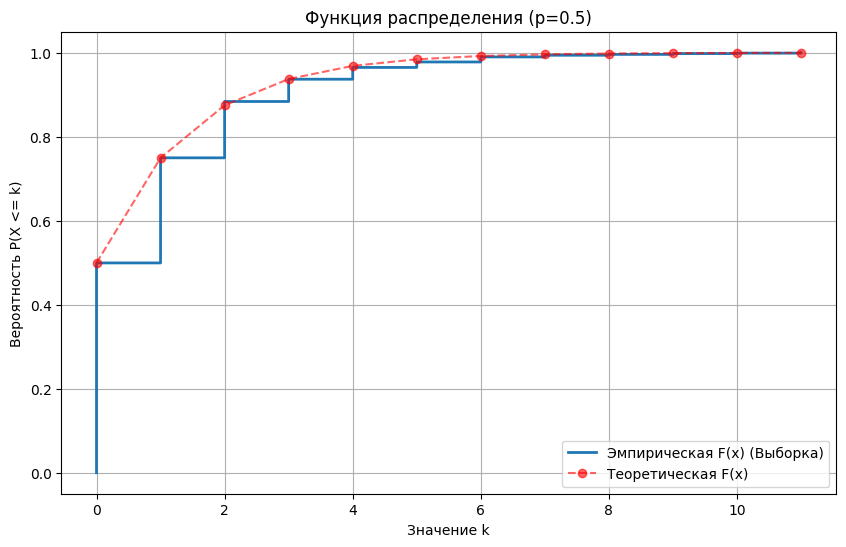

In [6]:
# ==========================================
# 5. ГРАФИКИ (ФУНКЦИИ РАСПРЕДЕЛЕНИЯ)
# ==========================================
# Эмпирическая функция F*(x)
x_vals = np.sort(df['val'])
y_vals = np.arange(1, len(x_vals) + 1) / len(x_vals)

# Теоретическая функция F(x) = 1 - (1-p)^(x+1)
x_theor = np.arange(0, x_vals.max() + 1)
y_theor = 1 - (1 - P_PARAM)**(x_theor + 1)

plt.figure(figsize=(10, 6))
plt.step(x_vals, y_vals, where='post', label='Эмпирическая F(x) (Выборка)', linewidth=2)
plt.plot(x_theor, y_theor, 'ro--', label='Теоретическая F(x)', alpha=0.6)
plt.title(f'Функция распределения (p={P_PARAM})')
plt.xlabel('Значение k')
plt.ylabel('Вероятность P(X <= k)')
plt.legend()
plt.grid(True)
plt.show()